# 🤖 Agentic RAG with Tools and Conversation Memory - Tesla Vehicle Manual

**Author:** *José Ignacio Orlando, PhD*

In this example, we extend the basic RAG application from `agentic-rag-product-support.ipynb` by introducing **tool calling** and **conversation memory**. This demonstrates how to:

1. **Model retrieval as a tool**: Convert the retrieval process into a tool that the LLM can call when needed
2. **Bind tools to LLMs**: Use `bind_tools()` to give the LLM access to tools
3. **Maintain conversation memory**: Keep track of the conversation history using LangChain's message-based state
4. **Conditional routing**: Use LangGraph's conditional edges to route based on tool calls

This example builds on the concepts from the basic RAG notebook, so make sure you've completed that first. We'll reuse the vector database created in Part 1 of that notebook.

**Prerequisites**: Before running this notebook, you must first execute `agentic-rag-product-support.ipynb` to create the vector database files (`vector_store.faiss` and `vector_store_metadata.pkl`).


# Part 1: Data Ingestion

**Note**: This section is already covered in detail in `agentic-rag-product-support.ipynb`. We'll skip the data ingestion steps here and load the existing vector database. If you haven't created the vector database yet, please run Part 1 of the basic RAG notebook first.

The data ingestion process involves:
1. Extracting text from the PDF manual
2. Chunking the text into manageable segments
3. Generating embeddings using OpenAI
4. Storing embeddings in a FAISS vector database

For detailed instructions on data ingestion, refer to `agentic-rag-product-support.ipynb`.


# Part 2: Agent Application with Tools and Memory

In this section, we'll build a LangGraph agent that uses **tools** for retrieval and maintains **conversation memory**. The key differences from the basic RAG example are:

1. **Retrieval as a Tool**: Instead of always retrieving context, the LLM decides when to use the retrieval tool
2. **Message-Based State**: We use LangChain's message format to maintain conversation history
3. **Tool Binding**: Tools are bound to the LLM using `bind_tools()`, enabling automatic tool calling
4. **Conditional Routing**: The graph routes to tool execution only when the LLM requests it

This approach gives the agent more autonomy and allows for multi-turn conversations where the agent can remember previous interactions.


## Step 1 - Environment Setup and Load Vector Database

We start by loading the existing vector database created in the basic RAG example. This includes:

1. **Loading environment variables**: We use `python-dotenv` to securely load our OpenAI API key
2. **Loading the FAISS index**: Restore the vector embeddings we saved earlier
3. **Loading chunk metadata**: Restore the actual text chunks that correspond to each embedding
4. **Initializing the embedding model**: Set up the same embedding model we used during ingestion (must match for consistency)

**Note**: Make sure you've run `agentic-rag-product-support.ipynb` first, or the vector database files won't exist!


In [1]:
# Import environment variable management
from os import getenv  # Function to read environment variables
from dotenv import load_dotenv  # Function to load variables from .env file

# Import LangGraph components
from langgraph.graph import StateGraph, START, END  # Graph building components
from typing import TypedDict, Annotated, Sequence  # Type hints for state definition
from langchain_openai import ChatOpenAI  # OpenAI chat model interface
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage  # Message types
from langchain_core.tools import tool  # Decorator for creating tools
from operator import add as add_messages  # Operator for concatenating messages
from IPython.display import Image, display  # Visualization utilities

# Import FAISS for vector database operations
import faiss  # Facebook AI Similarity Search - lightweight vector database
import numpy as np  # Numerical operations for vectors
import pickle  # Serialization for loading metadata

# Import LangChain components for embeddings
from langchain_openai import OpenAIEmbeddings  # OpenAI embedding model interface

# Load environment variables from .env file
load_dotenv()

# Assert that the OpenAI API key is set, otherwise raise an error
assert getenv("OPENAI_API_KEY") is not None, "Please set OPENAI_API_KEY in .env or environment."

# Configuration constants
VECTOR_DB_PATH = "./vector_store.faiss"  # Path to the FAISS index (created in previous notebook)
METADATA_PATH = "./vector_store_metadata.pkl"  # Path to chunk metadata (created in previous notebook)
EMBEDDING_MODEL = getenv("OPENAI_EMBEDDINGS_MODEL", "text-embedding-3-small")  # Retrieve the embedding model from environment variables
OPENAI_MODEL = getenv("OPENAI_MODEL", "gpt-4o")  # Retrieve the LLM model from environment variables

# Initialize the embedding model (must match the one used during ingestion)
embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)

# Load the FAISS index from disk
vector_index = faiss.read_index(VECTOR_DB_PATH)
print(f"Loaded FAISS index with {vector_index.ntotal} vectors")

# Load the text chunks metadata
with open(METADATA_PATH, 'rb') as f:
    text_chunks = pickle.load(f)
print(f"Loaded {len(text_chunks)} text chunks")

# Configuration for retrieval
TOP_K = 3  # Number of most relevant chunks to retrieve for each query


Loaded FAISS index with 1096 vectors
Loaded 1096 text chunks


## Step 2 - Define the Agent State with Message-Based Memory

Unlike the basic RAG example that used a custom state structure, we'll use LangChain's **message-based state** pattern. This approach:

- **Maintains conversation history**: All messages (user, AI, and tool responses) are stored in sequence
- **Enables tool calling**: LangChain's tool calling mechanism works seamlessly with messages
- **Supports multi-turn conversations**: The agent can reference previous messages in the conversation

The `AgentState` uses `Annotated[Sequence[BaseMessage], add_messages]` which:
- Stores a sequence of messages (SystemMessage, HumanMessage, AIMessage, ToolMessage)
- Uses the `add_messages` operator to automatically concatenate new messages to existing ones
- Preserves the full conversation history throughout the graph execution

This is the standard pattern for building conversational agents with LangGraph.


In [2]:
# Define the state structure for our RAG agent with conversation memory
# Using Annotated with add_messages automatically concatenates new messages to existing ones
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]  # Sequence of messages that grows with each interaction


## Step 3 - Define the Retrieval Tool

In the basic RAG example, retrieval always happened as part of the workflow. Here, we'll model retrieval as a **tool** that the LLM can call when needed. This gives the agent more flexibility:

- **On-demand retrieval**: The LLM decides when to search for information
- **Multiple tool calls**: The agent can call the retrieval tool multiple times if needed
- **Tool composition**: Other tools can be added alongside retrieval

The `@tool` decorator from LangChain automatically:
- Creates a tool schema that the LLM understands
- Generates a description from the function docstring
- Handles input validation and type conversion

The retrieval tool performs semantic search using the same FAISS index and embedding model from Part 1.


In [3]:
# Define the retrieval tool using the @tool decorator
@tool
def search_tesla_manual(query: str) -> str:
    """
    Search the Tesla vehicle manual for information relevant to the user's query.
    
    Use this tool when you need to find specific information from the Tesla owner's manual
    to answer the user's question. The tool performs semantic search to find the most
    relevant sections of the manual.
    
    Args:
        query: The search query describing what information to find in the manual
        
    Returns:
        A formatted string containing the most relevant chunks from the manual
    """
    # Generate embedding for the query (same model as during ingestion)
    query_embedding = embeddings.embed_query(query)
    
    # Convert to NumPy array and normalize (required for cosine similarity)
    query_vector = np.array([query_embedding]).astype('float32')
    faiss.normalize_L2(query_vector)  # Normalize for cosine similarity
    
    # Search the FAISS index for the top-k most similar chunks
    distances, indices = vector_index.search(query_vector, TOP_K)
    
    # Retrieve the actual text chunks using the indices
    retrieved_chunks = [text_chunks[idx] for idx in indices[0]]
    
    # Format the results for the LLM
    formatted_results = []
    for i, (chunk, distance) in enumerate(zip(retrieved_chunks, distances[0]), 1):
        formatted_results.append(f"[Chunk {i}] (Similarity: {distance:.3f})\n{chunk}")
    
    result_text = "\n\n---\n\n".join(formatted_results)
    
    print(f"\n[search_tesla_manual] Searched for: '{query}'")
    print(f"[search_tesla_manual] Retrieved {len(retrieved_chunks)} chunks with similarity scores: {distances[0]}")
    
    return result_text if result_text else "No relevant information found in the manual."


## Step 4 - Initialize LLM and Bind Tools

Now we'll initialize the LLM and **bind the retrieval tool** to it. The `bind_tools()` method:

- **Enables tool calling**: The LLM can now decide when to use the tool
- **Provides tool schemas**: The LLM receives information about available tools and their parameters
- **Returns tool calls**: When the LLM wants to use a tool, it includes tool calls in its response

After binding, the LLM will automatically include tool calls in its responses when it determines that retrieval is needed to answer the user's question.


In [4]:
# Initialize the LLM
llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0)  # Temperature=0 for more deterministic answers

# Create a list of available tools
tools = [search_tesla_manual]

# Bind tools to the LLM
# This enables the LLM to decide when to call the retrieval tool
llm_with_tools = llm.bind_tools(tools)

print(f"Initialized LLM: {OPENAI_MODEL}")
print(f"Bound {len(tools)} tool(s) to the LLM")


Initialized LLM: gpt-5
Bound 1 tool(s) to the LLM


## Step 5 - Define the LLM Node

The LLM node is responsible for processing user messages and generating responses. It:

1. **Receives messages**: Gets the current conversation history from the state
2. **Adds system prompt**: Prepends a system message with instructions for the agent
3. **Calls the LLM**: Invokes the LLM with the conversation history
4. **Returns the response**: The LLM's response (which may include tool calls) is added to the state

The system prompt instructs the agent to:
- Use the retrieval tool when it needs information from the manual
- Answer based only on retrieved information
- Maintain a helpful and accurate tone

Since we're using `add_messages` in the state, the new AI message is automatically concatenated to the existing messages.


In [5]:
# Define the system prompt for the agent
system_prompt = (
    "You are a helpful assistant for Tesla vehicle owners. "
    "Your role is to answer questions about Tesla vehicles based on information from the owner's manual. "
    "\n"
    "When you need information to answer a question, use the search_tesla_manual tool to find relevant sections. "
    "You can call this tool multiple times if needed to gather comprehensive information. "
    "\n"
    "Answer based only on the information you retrieve from the manual. "
    "If the information is not in the manual, politely say that you cannot answer based on the available information. "
    "Be accurate, clear, and helpful. "
    "Always cite which parts of the manual you used in your answers."
)

# Node function for calling the LLM
def call_llm(state: AgentState) -> AgentState:
    """
    Call the LLM with the current conversation history.
    
    This node processes the messages in the state, adds a system prompt,
    and invokes the LLM. The LLM may include tool calls in its response
    if it needs to retrieve information from the manual.
    """
    # Get messages from state
    messages = list(state['messages'])
    
    # Add system prompt at the beginning (only if not already present)
    if not messages or not isinstance(messages[0], SystemMessage):
        messages = [SystemMessage(content=system_prompt)] + messages
    
    # Call the LLM with tools bound
    response = llm_with_tools.invoke(messages)
    
    print(f"\n[call_llm] LLM response generated")
    if hasattr(response, 'tool_calls') and response.tool_calls:
        print(f"[call_llm] LLM requested {len(response.tool_calls)} tool call(s)")
    
    # Return the response message (will be added to state via add_messages)
    return {'messages': [response]}


## Step 6 - Define the Tool Execution Node

When the LLM includes tool calls in its response, we need to execute those tools. This node:

1. **Extracts tool calls**: Gets the tool calls from the last message (the LLM's response)
2. **Executes each tool**: Calls the appropriate tool function with the provided arguments
3. **Creates tool messages**: Wraps the tool results in `ToolMessage` objects
4. **Returns tool messages**: These are added to the state and will be seen by the LLM in the next turn

The `ToolMessage` format is important because:
- It associates the result with the specific tool call (via `tool_call_id`)
- The LLM can match tool results to the original tool calls
- It maintains the conversation flow for multi-turn tool usage

After tool execution, the graph will route back to the LLM node so it can process the tool results and generate a final answer.


In [6]:
# Create a dictionary mapping tool names to tool functions for easy lookup
tools_dict = {tool.name: tool for tool in tools}

# Node function for executing tools
def execute_tools(state: AgentState) -> AgentState:
    """
    Execute tool calls from the LLM's response.
    
    This node processes tool calls, executes the corresponding tools,
    and returns ToolMessage objects with the results.
    """
    # Get the last message (should be an AIMessage with tool calls)
    last_message = state['messages'][-1]
    
    # Extract tool calls from the message
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        print("\n[execute_tools] No tool calls found in last message")
        return {'messages': []}  # No tools to execute
    
    tool_calls = last_message.tool_calls
    tool_messages = []
    
    # Execute each tool call
    for tool_call in tool_calls:
        tool_name = tool_call['name']
        tool_args = tool_call.get('args', {})
        tool_call_id = tool_call['id']
        
        print(f"\n[execute_tools] Executing tool: {tool_name}")
        print(f"[execute_tools] Arguments: {tool_args}")
        
        # Check if the tool exists
        if tool_name not in tools_dict:
            error_msg = f"Tool '{tool_name}' not found. Available tools: {list(tools_dict.keys())}"
            print(f"[execute_tools] ERROR: {error_msg}")
            tool_messages.append(
                ToolMessage(
                    content=error_msg,
                    tool_call_id=tool_call_id,
                    name=tool_name
                )
            )
        else:
            # Execute the tool
            try:
                result = tools_dict[tool_name].invoke(tool_args)
                tool_messages.append(
                    ToolMessage(
                        content=str(result),
                        tool_call_id=tool_call_id,
                        name=tool_name
                    )
                )
                print(f"[execute_tools] Tool execution successful")
            except Exception as e:
                error_msg = f"Error executing tool {tool_name}: {str(e)}"
                print(f"[execute_tools] ERROR: {error_msg}")
                tool_messages.append(
                    ToolMessage(
                        content=error_msg,
                        tool_call_id=tool_call_id,
                        name=tool_name
                    )
                )
    
    print(f"\n[execute_tools] Executed {len(tool_messages)} tool call(s)")
    
    # Return tool messages (will be added to state via add_messages)
    return {'messages': tool_messages}


In [7]:
# Function to determine if we should continue with tool execution
def should_continue(state: AgentState) -> str:
    """
    Check if the last message contains tool calls.
    
    Returns:
        "continue" if tools need to be executed, END otherwise
    """
    last_message = state['messages'][-1]
    
    # Check if the last message has tool calls
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        print(f"\n[should_continue] Routing to execute_tools (found {len(last_message.tool_calls)} tool call(s))")
        return "continue"
    else:
        print(f"\n[should_continue] Routing to END (no tool calls, conversation complete)")
        return END


## Step 8 - Build the LangGraph Workflow

Now we assemble our nodes into a complete LangGraph workflow with conditional routing. The workflow:

1. **START** → `call_llm` (process user message)
2. `call_llm` → **conditional routing**:
   - If tools are needed → `execute_tools` → `call_llm` (loop back)
   - If no tools → **END** (conversation complete)

The key features of this graph:
- **Entry point**: Starts with the LLM node
- **Conditional edges**: Routes based on whether tool calls are present
- **Looping capability**: Can loop between LLM and tools multiple times
- **Message accumulation**: All messages are preserved in the state throughout execution

This design allows the agent to:
- Make multiple tool calls if needed
- Process tool results and generate follow-up tool calls
- Maintain conversation context across multiple turns


In [8]:
# Create a new StateGraph using our AgentState
workflow = StateGraph(AgentState)

# Register nodes
workflow.add_node("llm", call_llm)  # Node 1: Call the LLM
workflow.add_node("tools", execute_tools)  # Node 2: Execute tools

# Set the entry point (where the graph starts)
workflow.set_entry_point("llm")

# Add conditional edge from LLM: route to tools if tool calls are present, otherwise END
workflow.add_conditional_edges(
    "llm",
    should_continue,  # Function that determines the next step
    {
        "continue": "tools",  # If tools needed, go to tools node
        END: END  # If no tools, end the workflow
    }
)

# After executing tools, always go back to the LLM to process the results
workflow.add_edge("tools", "llm")

# Compile the workflow into an executable application
rag_agent = workflow.compile()

print("RAG agent with tools and conversation memory compiled successfully!")


RAG agent with tools and conversation memory compiled successfully!


Let's visualize our RAG workflow to see how the nodes are connected:


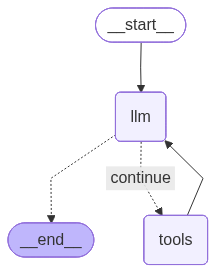

In [9]:
# Visualize the RAG workflow graph
display(Image(rag_agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))


## Step 9 - Test the RAG Agent with Tools and Memory

Now let's test our enhanced RAG agent. This demonstrates:

1. **Automatic tool calling**: The LLM decides when to use the retrieval tool
2. **Multi-turn conversations**: The agent maintains conversation history
3. **Follow-up questions**: The agent can answer follow-up questions using previous context

Notice how the agent:
- Automatically calls the retrieval tool when it needs information
- Processes tool results and generates comprehensive answers
- Remembers previous messages in the conversation


In [10]:
# Helper function to ask a question and get an answer
def ask_question(question: str, state: AgentState = None) -> AgentState:
    """
    Ask a question to the RAG agent and get an answer.
    
    Args:
        question: The user's question about the Tesla manual
        state: Optional previous state to continue the conversation
        
    Returns:
        The final state containing all messages in the conversation
    """
    # Create initial state or use existing state
    if state is None:
        initial_state: AgentState = {
            "messages": [HumanMessage(content=question)]
        }
    else:
        # Add the new question to existing state
        initial_state = {
            "messages": [HumanMessage(content=question)]
        }
        # Merge with existing messages (in a real app, you'd use the previous state directly)
        initial_state['messages'] = list(state['messages']) + initial_state['messages']
    
    # Execute the RAG agent
    result = rag_agent.invoke(initial_state)
    
    return result

# Test 1: Single question with automatic tool calling
print("="*70)
print("Test 1: Single question (agent will automatically use retrieval tool)")
print("="*70)
QUESTION_1 = "Question: How do I adjust the mirrors in my Tesla?"
print(QUESTION_1)
result1 = ask_question(QUESTION_1)
print(f"\n{'='*70}")
print("Final Answer:")
print(f"{'='*70}")
print(result1['messages'][-1].content)
print(f"\n{'-'*70}\n")

# Test 2: Follow-up question (demonstrates conversation memory)
print("="*70)
print("Follow up question: Follow-up question (using conversation memory)")
print("="*70)
QUESTION_2 = "What about the rear view mirror?"
print(QUESTION_2)
result2 = ask_question(QUESTION_2, state=result1)
print(f"\n{'='*70}")
print("Final Answer:")
print(f"{'='*70}")
print(result2['messages'][-1].content)
print(f"\n{'-'*70}\n")

# Test 3: Another question
print("="*70)
print("New question: Another question but about battery")
print("="*70)
QUESTION_3 = "What should I do if my Tesla battery runs out?"
print(QUESTION_3)
result3 = ask_question(QUESTION_3)
print(f"\n{'='*70}")
print("Final Answer:")
print(f"{'='*70}")
print(result3['messages'][-1].content)
print(f"\n{'-'*70}")

# Test 3: Another unrelated question
print("="*70)
print("New question but totally unrelated to Tesla")
print("="*70)
QUESTION_3 = "What is the best way to cook a steak?"
print(QUESTION_3)
result3 = ask_question(QUESTION_3)
print(f"\n{'='*70}")
print("Final Answer:")
print(f"{'='*70}")
print(result3['messages'][-1].content)
print(f"\n{'-'*70}")


Test 1: Single question (agent will automatically use retrieval tool)
Question: How do I adjust the mirrors in my Tesla?



[call_llm] LLM response generated
[call_llm] LLM requested 1 tool call(s)

[should_continue] Routing to execute_tools (found 1 tool call(s))

[execute_tools] Executing tool: search_tesla_manual
[execute_tools] Arguments: {'query': 'adjust mirrors side mirrors Tesla how to adjust mirrors screen controls steering wheel left right manual'}

[search_tesla_manual] Searched for: 'adjust mirrors side mirrors Tesla how to adjust mirrors screen controls steering wheel left right manual'
[search_tesla_manual] Retrieved 3 chunks with similarity scores: [0.6714564 0.6677002 0.6554756]
[execute_tools] Tool execution successful

[execute_tools] Executed 1 tool call(s)

[call_llm] LLM response generated
[call_llm] LLM requested 1 tool call(s)

[should_continue] Routing to execute_tools (found 1 tool call(s))

[execute_tools] Executing tool: search_tesla_manual
[execute_tools] Arguments: {'query': 'rearview mirror adjust interior mirror Model 3 manual adjust rear view mirror auto-dimming'}

[search_t

**What just happened?**

Our RAG agent with tools successfully:
- **Automatically decided** when to use the retrieval tool based on the question
- **Executed the tool** to search the manual for relevant information
- **Processed tool results** and generated comprehensive answers
- **Maintained conversation history** across multiple interactions

The key difference from the basic RAG example is that the agent has **autonomy** to decide when retrieval is needed, and it can make **multiple tool calls** if necessary. The message-based state ensures that all conversation context is preserved.
